In [3]:
import sys
from pathlib import Path
from dotenv import load_dotenv

# Ajouter la racine du projet au PYTHONPATH
PROJECT_ROOT = Path().cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

print("Project root added:", PROJECT_ROOT)

# Charger le .env
load_dotenv(PROJECT_ROOT / "config" / ".env")

print("ENV loaded from:", PROJECT_ROOT / "config" / ".env")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils.s3_io import read_parquet_from_s3

Project root added: c:\Users\mirei\Desktop\BiblioTech
ENV loaded from: c:\Users\mirei\Desktop\BiblioTech\config\.env


### Chargement des données depuis MinIO

In [4]:
books = read_parquet_from_s3("silver", "books_clean.parquet")
users = read_parquet_from_s3("silver", "users_clean.parquet")
ratings = read_parquet_from_s3("silver", "ratings_joinable.parquet")
popularity = read_parquet_from_s3("gold", "book_popularity.parquet")

print("Books:", books.shape)
print("Users:", users.shape)
print("Ratings:", ratings.shape)
print("Popularity:", popularity.shape)

books.head()

ratings.head()

Books: (271062, 8)
Users: (278858, 4)
Ratings: (383851, 3)
Popularity: (149721, 11)


,user_id,isbn,rating
0,276726,0155061224,5
1,276729,052165615X,3
2,276729,0521795028,6
3,276744,038550120X,7
4,276747,0060517794,9


### Vue d’ensemble des datasets

Le dataset contient :

- **271 062 livres** avec leurs métadonnées (titre, auteur, année, etc.)
- **278 858 utilisateurs** avec leurs informations (âge, localisation)
- **383 851 interactions explicites (ratings)** entre utilisateurs et livres
- **149 721 livres enrichis** dans la table `book_popularity`

On remarque que :
- le nombre de ratings est relativement faible comparé au nombre total d’utilisateurs et de livres
- tous les livres ne sont pas notés (149k vs 271k)

Cela indique une **forte sparsité du dataset**, caractéristique classique des systèmes de recommandation.

### Aperçu des données de ratings

Chaque ligne représente une interaction entre un utilisateur et un livre :

- `user_id` : identifiant unique de l’utilisateur
- `isbn` : identifiant du livre
- `rating` : note donnée par l’utilisateur (entre 1 et 10)

Exemple :
- l’utilisateur 276726 a attribué une note de 5 au livre 0155061224

Ce format correspond à une structure classique de **données implicites/explicites pour la recommandation** (user-item interactions).

### Premières observations

- Le dataset est structuré sous forme de **relations utilisateur → livre**
- Chaque utilisateur peut noter plusieurs livres
- Chaque livre peut être noté par plusieurs utilisateurs

Nous sommes donc dans un **problème typique de recommandation collaborative**

---

### Limite importante

- Le nombre de ratings (≈ 380k) est faible par rapport au nombre total de livres (≈ 270k)
- Beaucoup de livres ont peu ou pas de notes

Cela entraîne une **matrice utilisateur-livre très creuse (sparse)**, ce qui impactera les modèles de recommandation.

### Types et valeurs manquantes

In [5]:
books.info()
ratings.info()
books.isna().sum()
users.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 271062 entries, 0 to 271061
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   isbn                 271062 non-null  str    
 1   title                271062 non-null  str    
 2   author               271062 non-null  str    
 3   year_of_publication  266435 non-null  float64
 4   publisher            271060 non-null  str    
 5   image_url_s          271062 non-null  str    
 6   image_url_m          271062 non-null  str    
 7   image_url_l          271062 non-null  str    
dtypes: float64(1), str(7)
memory usage: 83.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 383851 entries, 0 to 383850
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   user_id  383851 non-null  int64
 1   isbn     383851 non-null  str  
 2   rating   383851 non-null  int64
dtypes: int64(2), str(1)
memory usage: 12.4 MB


user_id          0
location         0
age         112197
country         61
dtype: int64

### Statistiques globales

In [6]:
print("Nombre de livres :", books["isbn"].nunique())
print("Nombre d'utilisateurs :", users["user_id"].nunique())
print("Nombre de ratings :", ratings.shape[0])

print("Note moyenne globale :", ratings["rating"].mean())

Nombre de livres : 271062
Nombre d'utilisateurs : 278858
Nombre de ratings : 383851
Note moyenne globale : 7.626691085864047


## Analyse des ratings 

### Distribution des notes

rating
1      1481
2      2375
3      5119
4      7617
5     45355
6     31689
7     66404
8     91805
9     60780
10    71226
Name: count, dtype: int64


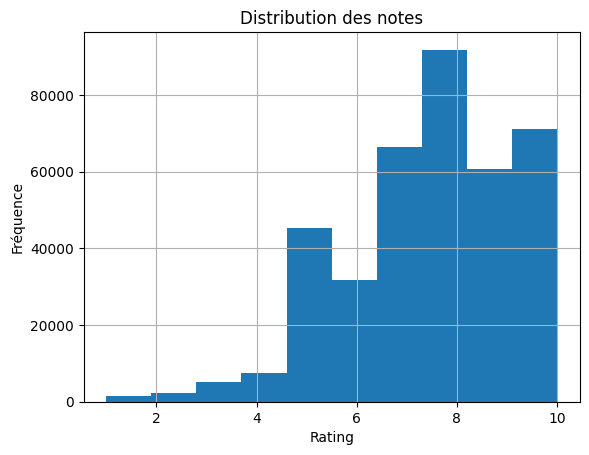

In [16]:
print(ratings["rating"].value_counts().sort_index())

plt.figure()
ratings["rating"].hist(bins=10)
plt.title("Distribution des notes")
plt.xlabel("Rating")
plt.ylabel("Fréquence")
plt.show()

In [17]:
ratings["rating"].mean()

np.float64(7.626691085864047)

### Distribution des notes utilisateurs

La distribution des notes montre une forte concentration sur les valeurs élevées :

- Les notes les plus fréquentes sont :
  - 8 (≈ 91 000)
  - 10 (≈ 71 000)
  - 7 (≈ 66 000)
  - 9 (≈ 60 000)

- Les notes faibles (1 à 4) sont très rares :
  - moins de 8 000 occurrences chacune

---

### Interprétation

On observe un **biais positif marqué** dans les évaluations :

- les utilisateurs donnent majoritairement des notes élevées
- les notes faibles sont peu utilisées

Cela signifie que :
- les utilisateurs notent surtout les livres qu’ils apprécient
- les avis négatifs sont sous-représentés

---

### Implications pour l’analyse

Ce biais entraîne :

- une **note moyenne globalement élevée** (7,6)
- une difficulté à différencier les bons livres des excellents
- une distribution déséquilibrée

---

### Implications pour les modèles de recommandation

Ce type de distribution peut poser plusieurs problèmes :

- les modèles peuvent avoir du mal à discriminer les préférences
- risque de recommander uniquement des contenus "populaires"
- nécessité de :
  - normaliser les notes
  - utiliser des scores pondérés (déjà fait avec `weighted_score`)
  - ou privilégier des approches de ranking plutôt que de prédiction brute

---

### Conclusion

La distribution des notes confirme que le dataset présente :
- un biais utilisateur classique
- une forte asymétrie

Ce comportement est typique des plateformes de recommandation (livres, films, etc.).

### Activité des utilisateurs

count    68092.000000
mean         5.637241
std         41.742618
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       6943.000000
Name: rating, dtype: float64


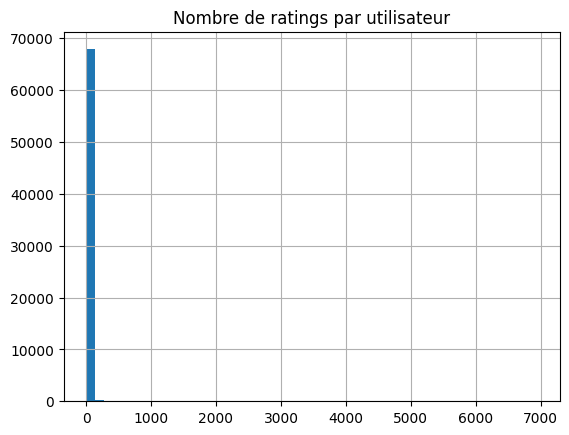

In [8]:
ratings_per_user = ratings.groupby("user_id")["rating"].count()

print(ratings_per_user.describe())
plt.figure()
ratings_per_user.hist(bins=50)
plt.title("Nombre de ratings par utilisateur")
plt.show()

### Activité des utilisateurs (nombre de ratings par utilisateur)

Les statistiques montrent une très forte inégalité dans l’activité des utilisateurs :

- Nombre moyen de ratings par utilisateur : ≈ 5.6
- Médiane : 1 rating
- 75% des utilisateurs ont au maximum 3 ratings
- Certains utilisateurs très actifs peuvent aller jusqu’à 6943 ratings


### Interprétation

On observe une distribution **très asymétrique** :

- la majorité des utilisateurs sont peu actifs (1 à 3 interactions)
- une minorité d’utilisateurs produit un grand volume de données

Cela correspond à un phénomène classique appelé :
**long tail des utilisateurs**


### Implications pour l’analyse

- les statistiques globales peuvent être biaisées par quelques utilisateurs très actifs
- la majorité des utilisateurs apporte peu d’information


### Implications pour la recommandation

Ce comportement pose plusieurs défis :

#### 1. Cold Start
- beaucoup d’utilisateurs ont trop peu de données
- difficile de personnaliser les recommandations

#### 2. Déséquilibre des données
- les modèles peuvent être dominés par les utilisateurs très actifs

#### 3. Sparsité élevée
- la matrice utilisateur-livre est très creuse


### Conséquences pour la suite du projet

Il sera nécessaire de :

- filtrer les utilisateurs trop peu actifs (ex : ≥ 5 ratings)
- ou utiliser des méthodes robustes à la sparsité
- éventuellement pondérer les utilisateurs


### Conclusion

Le dataset présente une forte hétérogénéité dans l’activité des utilisateurs, ce qui est typique des systèmes de recommandation et doit être pris en compte dans la conception des modèles.

### Popularité des livres

count    149721.000000
mean          2.563775
std           7.512179
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         707.000000
Name: rating, dtype: float64


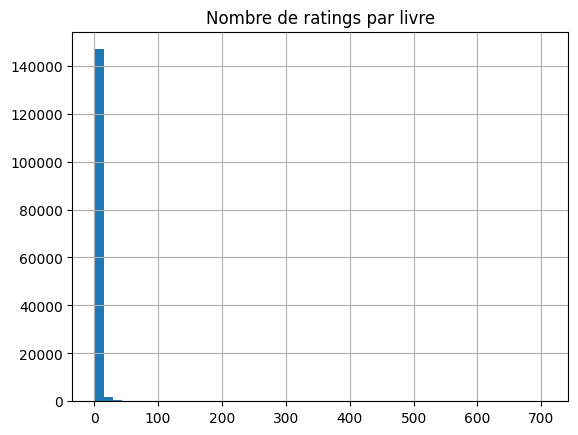

In [9]:
ratings_per_book = ratings.groupby("isbn")["rating"].count()

print(ratings_per_book.describe())
plt.figure()
ratings_per_book.hist(bins=50)
plt.title("Nombre de ratings par livre")
plt.show()

### Popularité des livres (nombre de ratings par livre)

Les statistiques montrent que :

- Nombre moyen de ratings par livre : ≈ 2.56
- Médiane : 1 rating
- 75% des livres ont au maximum 2 ratings
- Certains livres très populaires peuvent atteindre plus de 700 ratings


### Interprétation

On observe une distribution extrêmement déséquilibrée :

- la grande majorité des livres ont très peu de ratings (1 ou 2)
- une minorité de livres concentre un grand nombre d’interactions

Cela correspond au phénomène de :
**long tail des contenus**


### Implications pour l’analyse

- la plupart des livres sont peu connus ou peu évalués
- les statistiques globales sont dominées par quelques livres populaires


### Implications pour la recommandation

#### 1. Problème de sparsité
- la majorité des livres n’ont pas assez de données pour être recommandés efficacement

#### 2. Biais de popularité
- les modèles risquent de recommander uniquement les livres très populaires

#### 3. Difficulté d’évaluation
- les livres peu notés ont des moyennes peu fiables


### Conséquences pour la suite du projet

Il sera pertinent de :

- filtrer les livres avec trop peu de ratings (ex : ≥ 5 ou ≥ 10)
- utiliser un score pondéré (`weighted_score`) pour éviter les biais
- envisager des approches hybrides (content-based + collaborative)


### Conclusion

Le dataset présente une forte concentration des interactions sur un petit nombre de livres, ce qui est typique des systèmes de recommandation et renforce la nécessité d’adapter les méthodes utilisées.

## ANALYSE DES LIVRES

### Année de piblication

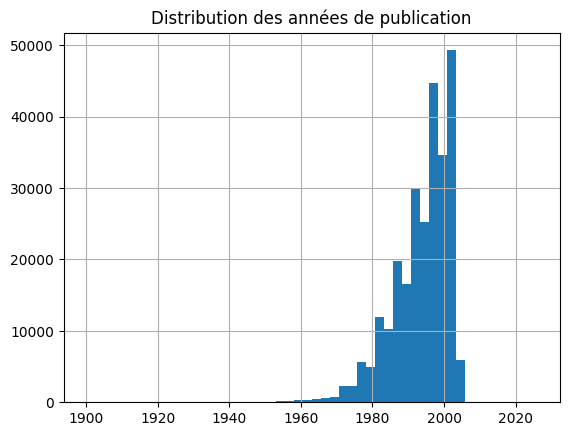

In [10]:
books["year_of_publication"].describe()


plt.figure()
books["year_of_publication"].dropna().hist(bins=50)
plt.title("Distribution des années de publication")
plt.show()

### Top auteurs

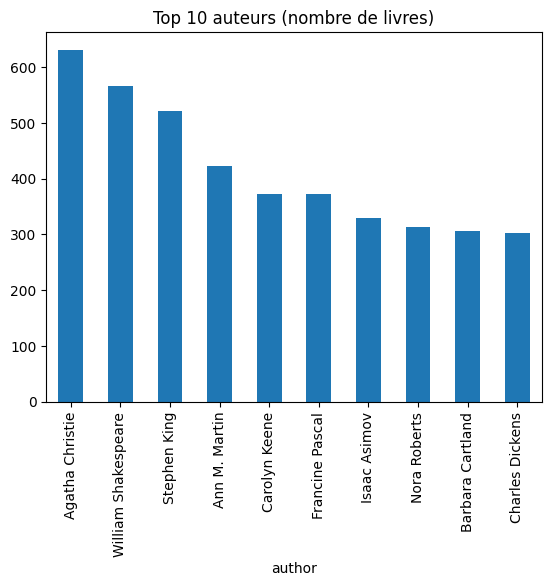

In [11]:
top_authors = books["author"].value_counts().head(10)
top_authors  #vérification 

top_authors.plot(kind="bar")
plt.title("Top 10 auteurs (nombre de livres)")
plt.show()

## Analyse croisée

### Jointures livres + ratings

In [12]:
merged = ratings.merge(books, on="isbn", how="inner")
merged.head()

,user_id,isbn,rating,title,author,year_of_publication,publisher,image_url_s,image_url_m,image_url_l
0,276726,0155061224,5,Rites of Passage,Judith Rae,2001.0,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
1,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
2,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
3,276744,038550120X,7,A Painted House,JOHN GRISHAM,2001.0,Doubleday,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...
4,276747,0060517794,9,Little Altars Everywhere,Rebecca Wells,2003.0,HarperTorch,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...


### Livres les plus populaires

In [13]:
top_books = (
    merged.groupby("title")["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_books

title
The Lovely Bones: A Novel                           707
Wild Animus                                         581
The Da Vinci Code                                   494
The Secret Life of Bees                             406
The Nanny Diaries: A Novel                          393
The Red Tent (Bestselling Backlist)                 383
Bridget Jones's Diary                               377
A Painted House                                     366
Life of Pi                                          336
Harry Potter and the Chamber of Secrets (Book 2)    326
Name: rating, dtype: int64

### Auteurs les plus populaires

In [14]:
top_authors_popularity = (
    merged.groupby("author")["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_authors_popularity

author
Stephen King          4639
Nora Roberts          2938
John Grisham          2550
James Patterson       2387
J. K. Rowling         1746
Mary Higgins Clark    1677
Janet Evanovich       1490
Dean R. Koontz        1475
Anne Rice             1245
Sue Grafton           1235
Name: rating, dtype: int64

### Realtion popularité/note

            ratings_count  average_rating
isbn                                     
0000913154              1             8.0
0001046438              1             9.0
000104687X              1             6.0
0001047213              1             9.0
0001047973              2             9.0


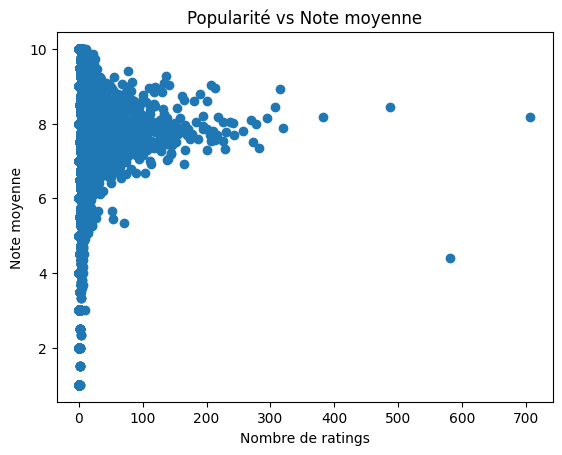

In [18]:
book_stats = (
    merged.groupby("isbn")
    .agg(
        ratings_count=("rating", "count"),
        average_rating=("rating", "mean")
    )
)

print(book_stats.head())

plt.figure()
plt.scatter(book_stats["ratings_count"], book_stats["average_rating"])
plt.xlabel("Nombre de ratings")
plt.ylabel("Note moyenne")
plt.title("Popularité vs Note moyenne")
plt.show()

### Relation entre popularité et note moyenne

Ce graphique représente la relation entre :
- le nombre de ratings d’un livre (popularité)
- sa note moyenne


### Observation principale

On observe une très forte concentration de points :

- la majorité des livres ont très peu de ratings (proche de 0–50)
- ces livres ont des notes très dispersées (de 1 à 10)

Cela confirme la forte **sparsité du dataset**


### Instabilité des notes pour les livres peu notés

Pour les livres avec peu de ratings :

- la note moyenne varie énormément
- certains livres avec 1 ou 2 notes peuvent apparaître comme “très bons” (ex : note 9 ou 10)

Cela est **statistiquement peu fiable**


### Effet de stabilisation

À mesure que le nombre de ratings augmente :

- les notes se concentrent dans une zone plus stable (environ 6 à 9)
- les valeurs extrêmes disparaissent

Cela s’explique par la loi des grands nombres :
plus un livre est noté, plus sa moyenne devient représentative


### Absence de corrélation forte

On n’observe pas de relation linéaire claire entre :

- popularité
- note moyenne

Un livre très populaire n’est pas forcément mieux noté


### Implications pour la recommandation

Ce résultat est critique :

#### 1. Ne pas utiliser uniquement la moyenne
- les livres peu notés peuvent être surévalués

#### 2. Importance du score pondéré
- le `weighted_score` permet de corriger ce biais
- il favorise les livres avec suffisamment de ratings

#### 3. Gestion de la long tail
- il faut éviter de recommander uniquement :
  - soit des livres peu fiables
  - soit uniquement les plus populaires


### Conclusion

La relation entre popularité et note montre que :

- la qualité perçue d’un livre dépend fortement du volume de données disponibles
- il est nécessaire d’intégrer la popularité dans l’évaluation des livres

Ce constat justifie l’utilisation d’un score ajusté dans le pipeline (table gold).